# AtlasFix — Notebook 01 : Exploration des données (EDA)

Ce notebook explore les données synthétiques générées.
Objectif : comprendre les distributions, détecter les problèmes, et préparer les features pour les modèles ML.

**Ordre du notebook :**
1. Chargement des données
2. Exploration des artisans
3. Exploration des offres acceptées (vérité terrain pricing)
4. Exploration des interactions (vérité terrain matching)
5. Corrélations et features importantes
6. Conclusions pour la modélisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# Style simple et lisible
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11

# Chemins
import os
DATA_DIR = os.path.join('..', 'data', 'raw')

print('Librairies chargées ✓')

Librairies chargées ✓


## 1. Chargement des données

In [2]:
artisans     = pd.read_csv(os.path.join(DATA_DIR, 'artisans.csv'))
clients      = pd.read_csv(os.path.join(DATA_DIR, 'clients.csv'))
demands      = pd.read_csv(os.path.join(DATA_DIR, 'demands.csv'))
offers       = pd.read_csv(os.path.join(DATA_DIR, 'accepted_offers.csv'))
interactions = pd.read_csv(os.path.join(DATA_DIR, 'interactions.csv'))

print(f'Artisans          : {len(artisans)} lignes, {artisans.shape[1]} colonnes')
print(f'Clients           : {len(clients)} lignes')
print(f'Demandes          : {len(demands)} lignes')
print(f'Offres acceptées  : {len(offers)} lignes  ← cible du modèle pricing')
print(f'Interactions      : {len(interactions)} lignes  ← cible du modèle matching')

Artisans          : 300 lignes, 19 colonnes
Clients           : 400 lignes
Demandes          : 800 lignes
Offres acceptées  : 537 lignes  ← cible du modèle pricing
Interactions      : 3000 lignes  ← cible du modèle matching


## 2. Exploration des artisans

In [3]:
# Vue d'ensemble
artisans.head(3)

,id,name,phone,city,latitude,longitude,category,years_experience,hourly_rate,rating,n_reviews,response_time_h,response_rate,completion_rate,no_show_rate,is_verified,is_available,global_score,created_at
0,1,Olivier Grondin,638908386,Rabat,33.91820,-6.89024,Maçonnerie,19,192,4.3,22,1.8,0.64,0.96,0.11,1,1,0.737,2025-03-15
1,2,Céline Navarro,707816184,Fès,33.97175,-4.94303,Électricité,13,265,4.3,23,2.6,0.85,0.71,0.03,1,1,0.763,2025-01-28
2,3,Martin Blanc,683276483,Rabat,33.99498,-6.85167,Carrelage,23,246,4.4,68,5.6,0.89,0.77,0.00,1,1,0.948,2025-01-06


In [4]:
# Stats descriptives des colonnes numériques
artisans[['rating', 'n_reviews', 'years_experience', 'hourly_rate', 'global_score']].describe().round(2)

,rating,n_reviews,years_experience,hourly_rate,global_score
count,300.00,300.00,300.00,300.00,300.00
mean,4.10,63.41,12.78,216.98,0.76
std,0.56,38.28,7.42,78.42,0.10
min,2.70,0.00,1.00,81.00,0.46
25%,3.70,27.00,6.00,146.00,0.69
50%,4.10,62.00,13.00,220.50,0.76
75%,4.50,98.00,19.00,288.50,0.83
max,5.00,129.00,25.00,349.00,0.99


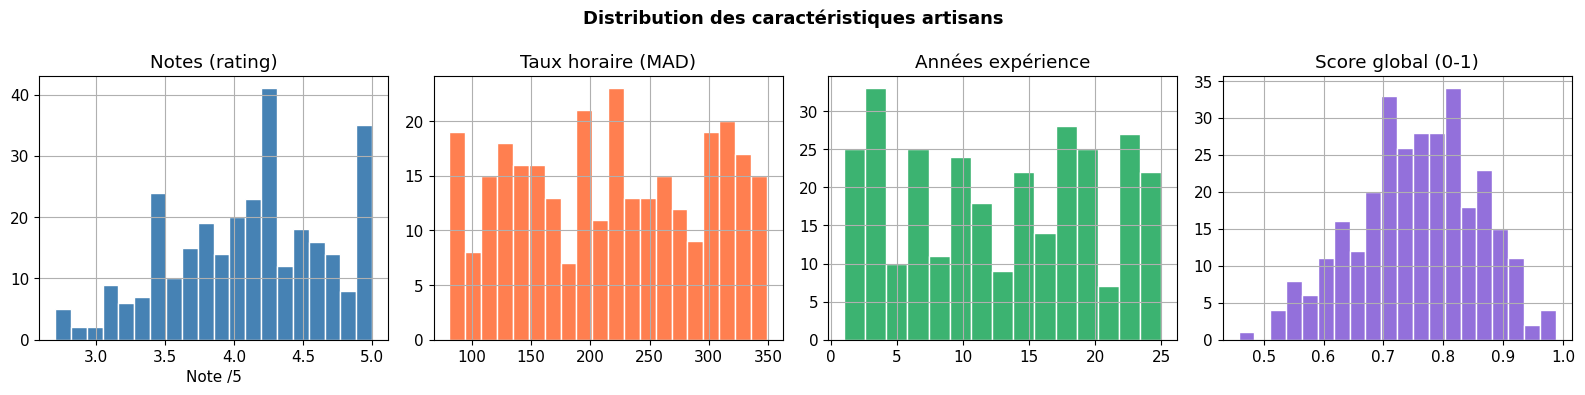

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Distribution des caractéristiques artisans', fontsize=13, fontweight='bold')

artisans['rating'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Notes (rating)')
axes[0].set_xlabel('Note /5')

artisans['hourly_rate'].hist(bins=20, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Taux horaire (MAD)')

artisans['years_experience'].hist(bins=15, ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Années expérience')

artisans['global_score'].hist(bins=20, ax=axes[3], color='mediumpurple', edgecolor='white')
axes[3].set_title('Score global (0-1)')

plt.tight_layout()
plt.show()

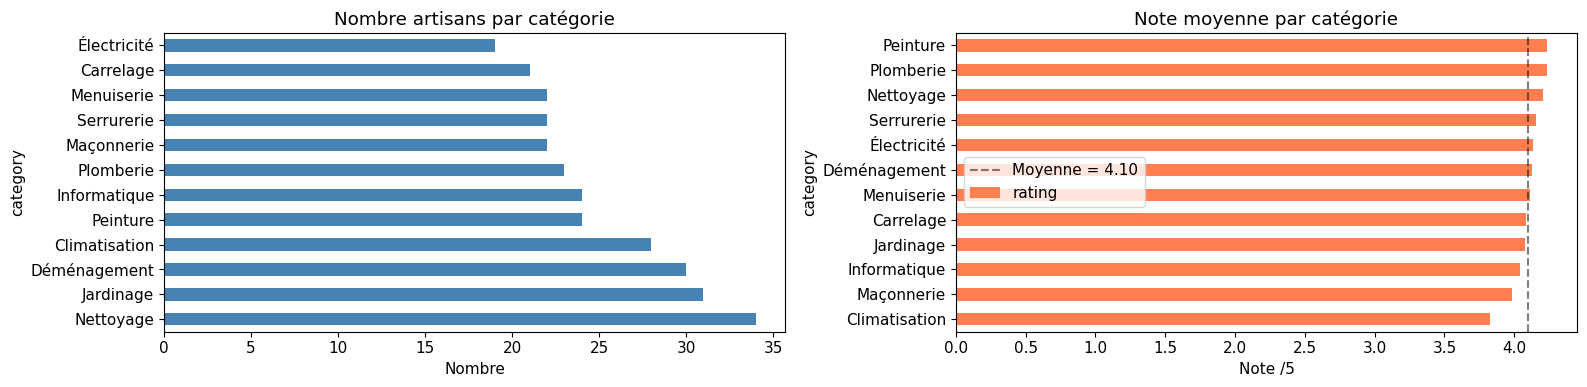

In [6]:
# Répartition par catégorie
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

cat_counts = artisans['category'].value_counts()
cat_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Nombre artisans par catégorie')
axes[0].set_xlabel('Nombre')

# Note moyenne par catégorie
artisans.groupby('category')['rating'].mean().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Note moyenne par catégorie')
axes[1].set_xlabel('Note /5')
axes[1].axvline(artisans['rating'].mean(), color='black', linestyle='--', alpha=0.5, label=f'Moyenne = {artisans["rating"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Taux de vérification et disponibilité
print('Artisans vérifiés  :', f"{artisans['is_verified'].mean()*100:.1f}%")
print('Artisans disponibles :', f"{artisans['is_available'].mean()*100:.1f}%")
print('Ville la plus représentée :', artisans['city'].value_counts().index[0])

Artisans vérifiés  : 58.0%
Artisans disponibles : 82.3%
Ville la plus représentée : Casablanca


## 3. Exploration des offres acceptées ← variable cible du pricing

In [8]:
offers.head(3)

,category,city,urgency,desc_len,n_photos,budget_min,budget_max,artisan_rating,artisan_score,artisan_exp,distance_km,same_city,accepted_price
0,Nettoyage,Marrakech,normal,250,0,70,780,5.0,0.804,6,655.55,0,401
1,Déménagement,Oujda,normal,168,3,210,2860,4.0,0.859,19,452.77,0,1353
2,Électricité,Oujda,urgent,129,0,140,1820,3.6,0.800,7,659.99,0,875


In [9]:
print('Variable cible → accepted_price')
print(offers['accepted_price'].describe().round(1))

Variable cible → accepted_price
count     537.0
mean     1039.6
std       802.7
min       100.0
25%       455.0
50%       793.0
75%      1386.0
max      4335.0
Name: accepted_price, dtype: float64


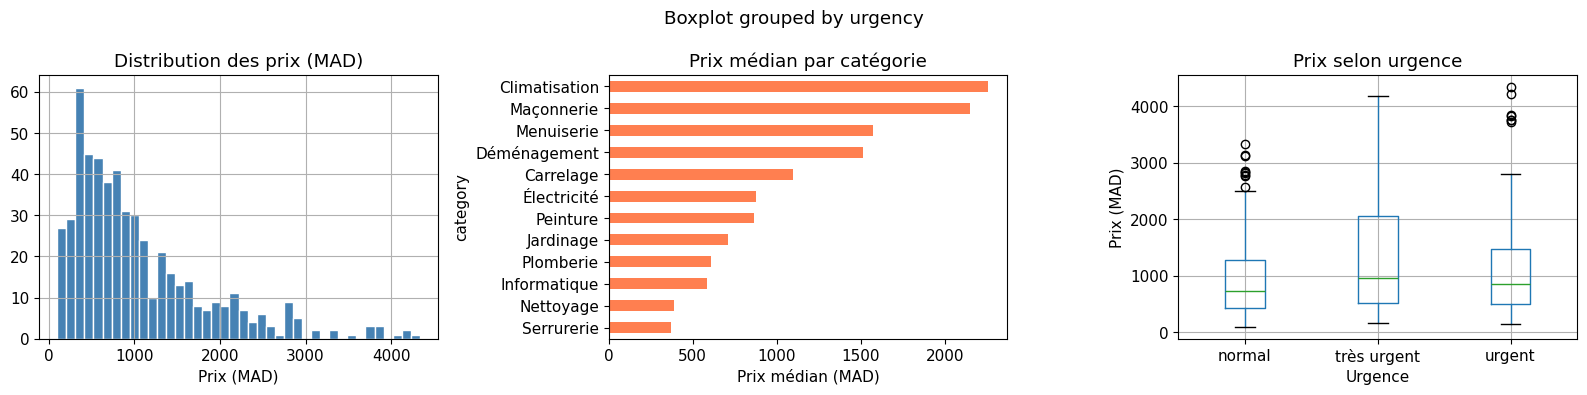

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Analyse du prix accepté (variable cible)', fontsize=13, fontweight='bold')

# Distribution globale
offers['accepted_price'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des prix (MAD)')
axes[0].set_xlabel('Prix (MAD)')

# Prix médian par catégorie
prix_cat = offers.groupby('category')['accepted_price'].median().sort_values()
prix_cat.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Prix médian par catégorie')
axes[1].set_xlabel('Prix médian (MAD)')

# Impact de l'urgence sur le prix
offers.boxplot(column='accepted_price', by='urgency', ax=axes[2])
axes[2].set_title('Prix selon urgence')
axes[2].set_xlabel('Urgence')
axes[2].set_ylabel('Prix (MAD)')
plt.sca(axes[2])
plt.title('Prix selon urgence')

plt.tight_layout()
plt.show()

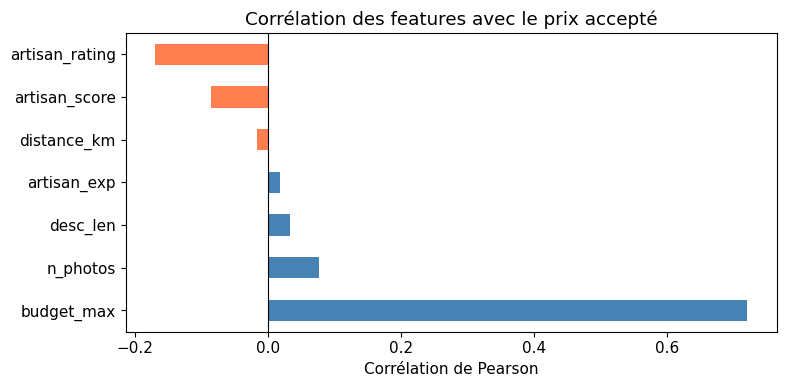


Conclusion : les features les plus corrélées avec le prix sont :
  budget_max           → +0.721
  n_photos             → +0.077
  desc_len             → +0.034


In [11]:
# Corrélations avec le prix accepté
num_cols = ['accepted_price', 'artisan_rating', 'artisan_score', 'artisan_exp',
            'distance_km', 'n_photos', 'desc_len', 'budget_max']

corr = offers[num_cols].corr()['accepted_price'].drop('accepted_price').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if x > 0 else 'coral' for x in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Corrélation des features avec le prix accepté')
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

print('\nConclusion : les features les plus corrélées avec le prix sont :')
for feat, val in corr.head(3).items():
    print(f'  {feat:<20} → {val:+.3f}')

## 4. Exploration des interactions ← vérité terrain matching

In [12]:
interactions.head(3)

,client_id,artisan_id,category,type,value,date
0,288,125,Jardinage,message_sent,0.6,2026-01-24
1,45,16,Peinture,view_profile,0.2,2025-09-01
2,103,66,Nettoyage,accept_offer,1.0,2026-04-21


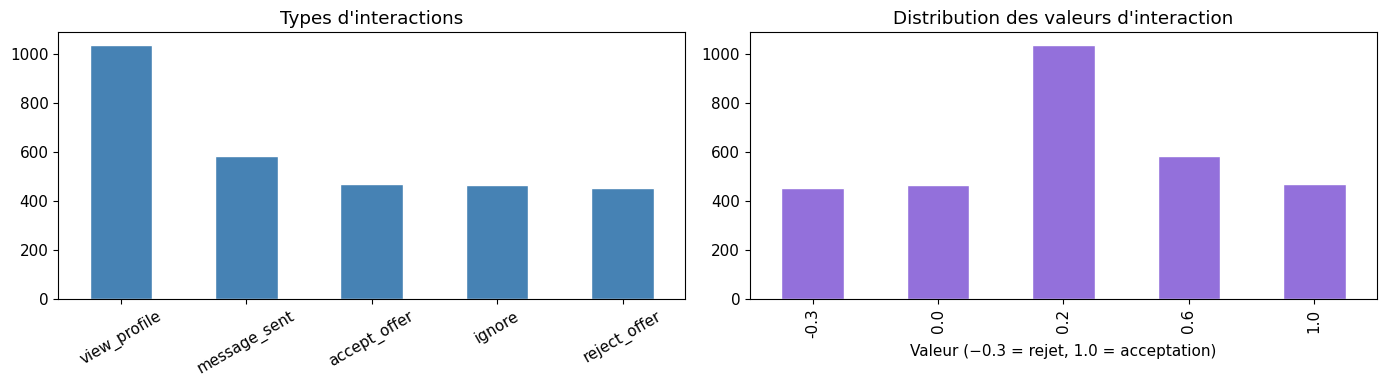

Taux d'acceptation : 15.6%
→ Déséquilibre de classes : à gérer avec scale_pos_weight dans LightGBM


In [13]:
# Répartition des types d'interactions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_counts = interactions['type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Types d\'interactions')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Distribution des valeurs d'interaction
interactions['value'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Distribution des valeurs d\'interaction')
axes[1].set_xlabel('Valeur (−0.3 = rejet, 1.0 = acceptation)')

plt.tight_layout()
plt.show()

n_accept = (interactions['type'] == 'accept_offer').sum()
print(f"Taux d'acceptation : {n_accept/len(interactions)*100:.1f}%")
print(f"→ Déséquilibre de classes : à gérer avec scale_pos_weight dans LightGBM")

In [14]:
# Artisans les plus interagis
top_artisans = interactions.groupby('artisan_id')['value'].sum().sort_values(ascending=False).head(10)
print('Top 10 artisans par score d\'interaction cumulé :')
print(top_artisans)

Top 10 artisans par score d'interaction cumulé :
artisan_id
122    7.5
274    7.4
205    7.3
17     7.1
101    6.9
27     6.5
175    6.2
247    6.1
189    6.0
96     5.8
Name: value, dtype: float64


## 5. Corrélations globales et feature importance préliminaire

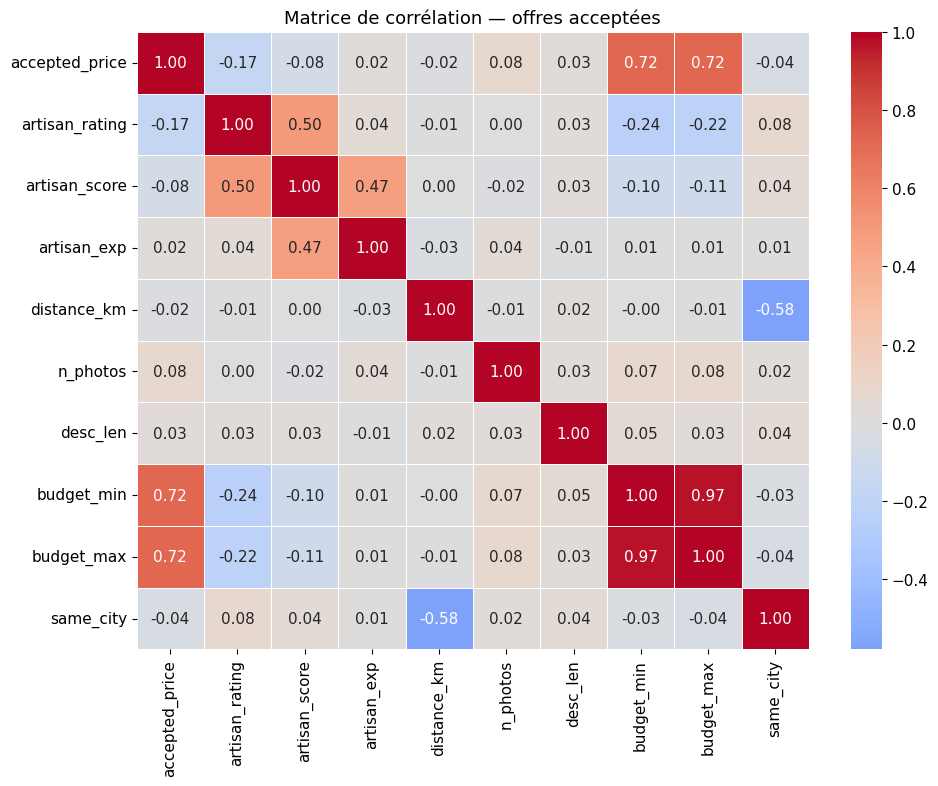

In [16]:
import seaborn as sns

numeric_offers = offers[['accepted_price', 'artisan_rating', 'artisan_score',
                          'artisan_exp', 'distance_km', 'n_photos',
                          'desc_len', 'budget_min', 'budget_max', 'same_city']]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    numeric_offers.corr().round(2),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.5
)
ax.set_title('Matrice de corrélation — offres acceptées', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusions pour la modélisation

À noter avant d'entraîner les modèles :

In [17]:
print('=== CONCLUSIONS EDA ===')
print()
print('PRICING MODEL :')
print(f'  - {len(offers)} exemples d\'entraînement')
print(f'  - Prix cible : {offers["accepted_price"].min():.0f} → {offers["accepted_price"].max():.0f} MAD')
print(f'  - Médiane : {offers["accepted_price"].median():.0f} MAD')
print(f'  - Features les plus importantes : budget_max, category, urgency, artisan_rating')
print(f'  - Modèle choisi : LightGBM quantile regression (Q25/Q75)')
print()
print('MATCHING MODEL :')
print(f'  - {len(interactions)} interactions enregistrées')
n_pos = (interactions['value'] == 1.0).sum()
print(f'  - Acceptations : {n_pos} ({n_pos/len(interactions)*100:.1f}%) → classe déséquilibrée')
print(f'  - Solution : scale_pos_weight = {int((len(interactions)-n_pos)/max(n_pos,1))} dans LightGBM')
print(f'  - Modèle choisi : LightGBM binary classifier')
print()
print('PROCHAINE ÉTAPE : notebooks/02_train_pricing.ipynb')

=== CONCLUSIONS EDA ===

PRICING MODEL :
  - 537 exemples d'entraînement
  - Prix cible : 100 → 4335 MAD
  - Médiane : 793 MAD
  - Features les plus importantes : budget_max, category, urgency, artisan_rating
  - Modèle choisi : LightGBM quantile regression (Q25/Q75)

MATCHING MODEL :
  - 3000 interactions enregistrées
  - Acceptations : 469 (15.6%) → classe déséquilibrée
  - Solution : scale_pos_weight = 5 dans LightGBM
  - Modèle choisi : LightGBM binary classifier

PROCHAINE ÉTAPE : notebooks/02_train_pricing.ipynb
